In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Explainer: "veto", "tendency", and why the additive model is misleading

This notebook exists to explain the words I invented and the claims behind them, slowly.
The results themselves are in [lexicographic.ipynb](lexicographic.ipynb) — this one is the
walkthrough.

**The question.** We show the model two laptops and it picks one. *How* does it decide?

**Two possible answers**, and they are very different:

1. It gives each feature a score and **adds them up**. A big enough advantage on one feature
   can make up for a loss on another.
2. It follows a **priority list**. It looks at the most important feature first. Only if that
   one is tied does it look at the next.

Everything we have fitted so far assumed answer 1. The data says answer 2.

## The data used everywhere below

One file per run: `data/<experiment>/<job id>/scores.csv`.

Each row is **one ordered pair** shown to the model:

| column | meaning |
|---|---|
| `a_brand, a_screen, a_ram` | the laptop shown as **Option 1** |
| `b_brand, b_screen, b_ram` | the laptop shown as **Option 2** |
| `score_a`, `score_b` | how strongly the model wanted to answer "Option 1" / "Option 2" |
| `template_idx` | which of the 5 prompt wordings was used |

There are 45 laptops (5 brands x 3 screens x 3 RAM sizes), every ordered pair, 5 wordings:
$45 \times 44 \times 5 = 9900$ rows per run.

I only ever use **who won**:

$$\text{margin} = \texttt{score\_a} - \texttt{score\_b}, \qquad
\text{margin} > 0 \;\Rightarrow\; \text{the model picked Option 1}$$

No Bradley-Terry, no log-odds, no magnitudes — because we established earlier that in this
data the *ordering* is trustworthy and the *sizes* are not. Everything in sections 1-3 is a
percentage you could count by hand.

`qwen-0.5B` is left out everywhere: it has no measurable preference on anything.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

BASE = ["data/laptops_robustness", "data/laptops_robustness_gemma"]
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
SC, RM = ["13-inch", "14-inch", "16-inch"], ["4GB", "8GB", "16GB"]
RORD = {"4GB": 0, "8GB": 1, "16GB": 2}          # "more is better" order
SORD = {"13-inch": 0, "14-inch": 1, "16-inch": 2}
LEVELS = {"brand": BRANDS, "screen": SC, "ram": RM}
REAL = [("qwen", s) for s in ["7", "32", "72"]] + [("gemma", s) for s in ["1", "4", "12", "27"]]

FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}
CONTRACT, OWN = "#2a78d6", "#e34948"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d1", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": "#e8e7e3", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
pd.set_option("display.width", 220)


def load():
    R, C = {}, {}
    for b in BASE:
        for run in sorted(os.listdir(b)):
            cp = os.path.join(b, run, "config.json")
            if not os.path.isfile(cp):
                continue
            c = json.load(open(cp))
            k = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            R[k] = pd.read_csv(os.path.join(b, run, "scores.csv"))
            C[k] = c["constraints"]
    return R, C


def margin(d):
    return (d.score_a - d.score_b).values


def wins(d, mask, a_is_candidate):
    """% of the selected rows where the flagged laptop is the one the model picked."""
    if mask.sum() == 0:
        return np.nan
    m, p = margin(d)[mask], a_is_candidate[mask]
    return 100 * float(np.mean(np.where(p, m > 0, m < 0)))


def fit_bt(df, feats=("brand", "screen", "ram")):
    """Sum-to-zero additive Bradley-Terry (used ONLY in section 2, to show it misleads)."""
    y = margin(df)
    cols, names = [np.ones(len(df))], ["gamma"]
    for f in feats:
        for l in LEVELS[f]:
            if l not in set(df["a_" + f]) | set(df["b_" + f]):
                continue
            cols.append((df["a_" + f].values == l).astype(float)
                        - (df["b_" + f].values == l).astype(float))
            names.append(f"{f}_{l}")
    w, *_ = np.linalg.lstsq(np.column_stack(cols), y, rcond=None)
    out = dict(zip(names, w))
    for f in feats:
        ks = [k for k in names if k.startswith(f + "_")]
        m = np.mean([out[k] for k in ks])
        for k in ks:
            out[k] -= m
    return out


RUNS, CONSTRAINTS = load()
print(f"{len(RUNS)} runs loaded")
print("keys look like:", list(RUNS)[0])

32 runs loaded
keys look like: ('qwen', '72', 'none')


# 1. The two theories, written out

## Theory 1 — additive (what we assumed)

Every level of every feature gets a number. A laptop's value is the sum:

$$u(x) \;=\; w_{\text{brand}}\big(\text{brand}(x)\big) \;+\; w_{\text{screen}}\big(\text{screen}(x)\big) \;+\; w_{\text{ram}}\big(\text{ram}(x)\big)$$

The model prefers $A$ to $B$ when $u(A) > u(B)$, that is when

$$\underbrace{\Delta w_{\text{brand}}}_{\text{brand gap}} \;+\; \underbrace{\Delta w_{\text{screen}}}_{\text{screen gap}} \;+\; \underbrace{\Delta w_{\text{ram}}}_{\text{RAM gap}} \;>\; 0$$

**The property that matters:** every feature can be outvoted by the others. There is always
an **exchange rate** — how much brand advantage is worth one RAM step:

$$\text{exchange rate} \;=\; \frac{w_{\text{ram}}(16\text{GB}) - w_{\text{ram}}(8\text{GB})}{w_{\text{brand}}(\text{Apple}) - w_{\text{brand}}(\text{HP})}$$

(In economics this is the *marginal rate of substitution*. A model with this property is
called **compensatory** — a loss on one feature can be *compensated* by a gain on another.)

## Theory 2 — a priority list

Put the features in order of importance, say $\text{ram} \succ \text{screen} \succ \text{brand}$.

$$
A \succ B \iff
\begin{cases}
\text{ram}(A) > \text{ram}(B), & \text{or}\\[4pt]
\text{ram}(A) = \text{ram}(B) \ \text{ and } \ \text{screen}(A) > \text{screen}(B), & \text{or}\\[4pt]
\text{ram}(A) = \text{ram}(B) \ \text{ and } \ \text{screen}(A) = \text{screen}(B) \ \text{ and } \ \text{brand}(A) \succ \text{brand}(B)
\end{cases}
$$

**The property that matters:** there is **no exchange rate**. No amount of brand ever buys
one RAM step. The standard name for this is a **lexicographic** preference — like sorting
words in a dictionary, where the first letter decides and the second letter only matters if
the first letters are equal. A model like this is called **non-compensatory**.

# 2. The words I used, defined

For a feature $f$, define its **decisiveness**: among the comparisons where the two laptops
*differ* on $f$, how often does the laptop with the better level of $f$ win?

$$D(f) \;=\; \Pr\Big[\ \text{the better-}f\text{ laptop wins} \ \Big|\ f(A) \neq f(B) \ \Big]$$

We measure it as a plain count over rows of `scores.csv`. Three cases:

| $D(f)$ | my word | standard term | what it means |
|---|---|---|---|
| $= 100\%$ | **veto** | non-compensatory / lexicographic in $f$ | this feature *always* decides. Nothing else can overrule it. |
| $50\% < D < 100\%$ | **tendency** | compensatory | it usually decides, but the other features can outvote it. |
| $= 50\%$ | **no effect here** | — | knowing $f$ tells you nothing about who won. |

A feature that is $50\%$ at the top level may still matter **lower down the list** — that is
what I called a **tie-breaker**. So we also measure $D(f)$ *conditional on the
higher-priority features being tied*:

$$D(\text{screen} \mid \text{RAM tied}), \qquad D(\text{brand} \mid \text{RAM and screen tied})$$

> **Important:** "better level" needs a direction. For RAM and screen I use the natural order
> ($16\text{GB} > 8\text{GB} > 4\text{GB}$, $16'' > 14'' > 13''$), and I check below that the
> models agree with it. Brand has no natural order, so for brand I track one brand (Apple)
> and report its win rate; $50\%$ means brand is doing nothing.

# 3. Three real comparisons

Before any statistics. All three are from `data/laptops_robustness/68373841/scores.csv`
(qwen-32B, no contract), averaged over the 5 prompt wordings.

In this run Apple is the **best** brand and HP the **worst**, so this is brand's best
possible case: Apple against HP.

In [3]:
d = RUNS[("qwen", "32", "none")]
w = fit_bt(d)
print(f"fitted brand weights: Apple {w['brand_Apple']:+.2f} (best), "
      f"HP {w['brand_HP']:+.2f} (worst)   -> a brand gap of {w['brand_Apple']-w['brand_HP']:.2f}\n")

ex = [("Apple", "14-inch", "8GB", "HP", "14-inch", "8GB", "RAM tied - brand is free to decide"),
      ("Apple", "16-inch", "8GB", "HP", "16-inch", "16GB", "HP has ONE more RAM step"),
      ("Apple", "13-inch", "4GB", "HP", "13-inch", "8GB", "HP has ONE more RAM step")]
rows = []
for ab, asc, ar, bb, bsc, br, note in ex:
    m = d[(d.a_brand == ab) & (d.a_screen == asc) & (d.a_ram == ar)
          & (d.b_brand == bb) & (d.b_screen == bsc) & (d.b_ram == br)]
    mm = float(margin(m).mean())
    rows.append({"Option 1": f"{asc} {ab} / {ar}", "Option 2": f"{bsc} {bb} / {br}",
                 "situation": note, "margin": round(mm, 2),
                 "model picks": "the Apple" if mm > 0 else "the HP"})
print(pd.DataFrame(rows).to_string(index=False))

fitted brand weights: Apple +2.21 (best), HP -1.60 (worst)   -> a brand gap of 3.82

           Option 1          Option 2                          situation  margin model picks
14-inch Apple / 8GB  14-inch HP / 8GB RAM tied - brand is free to decide    8.69   the Apple
16-inch Apple / 8GB 16-inch HP / 16GB           HP has ONE more RAM step  -32.84      the HP
13-inch Apple / 4GB  13-inch HP / 8GB           HP has ONE more RAM step  -36.07      the HP


**Read it like this.** When RAM is tied, the model takes the Apple. Give the HP just *one*
more RAM step and the model takes the HP — and not narrowly: the margin swings from $+8.7$
to about $-33$.

Apple is the best brand and HP the worst, so if brand could ever beat one RAM step, it would
be here. It cannot.

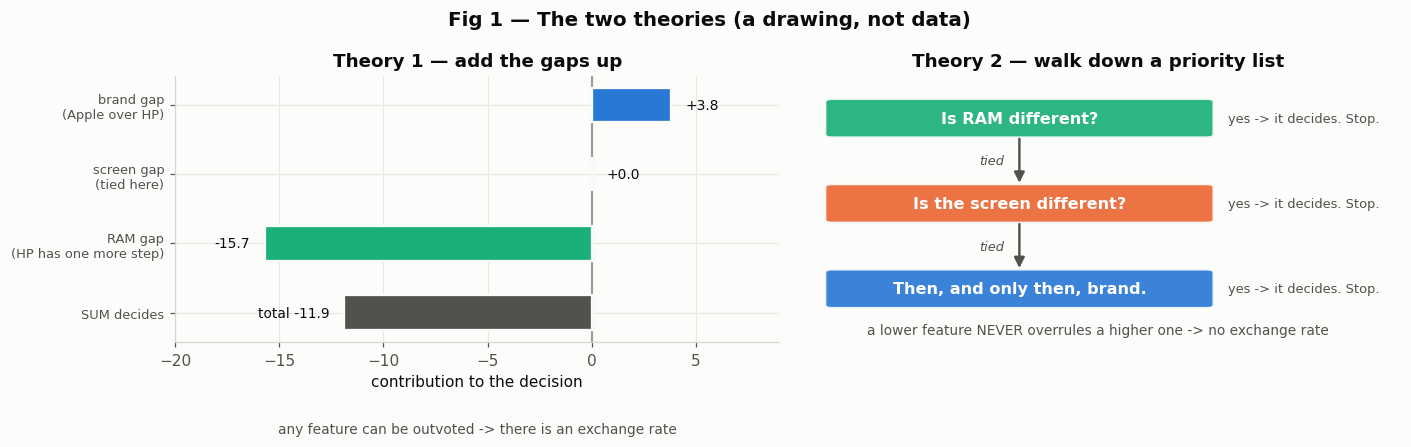

In [4]:
# --- Fig 1: the two theories side by side, as pictures ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.set_title("Theory 1 — add the gaps up", fontsize=12, fontweight="bold")
gaps = [("brand gap\n(Apple over HP)", +3.8, FEATURE_COLOR["brand"]),
        ("screen gap\n(tied here)", 0.0, FEATURE_COLOR["screen"]),
        ("RAM gap\n(HP has one more step)", -15.7, FEATURE_COLOR["ram"])]
y = np.arange(3)[::-1]
for i, (lab, v, c) in enumerate(gaps):
    ax.barh(y[i], v, 0.5, color=c, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.text(v + (0.7 if v >= 0 else -0.7), y[i], f"{v:+.1f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
tot = sum(g[1] for g in gaps)
ax.barh(-1, tot, 0.5, color=INK_MUTED, edgecolor=SURFACE, linewidth=1.5, zorder=3)
ax.text(tot - 0.7, -1, f"total {tot:+.1f}", va="center", ha="right", fontsize=9, color=INK)
ax.axvline(0, color="#9c9b98", linewidth=1.4)
ax.set_yticks(list(y) + [-1], [g[0] for g in gaps] + ["SUM decides"], fontsize=8.5)
ax.set_xlabel("contribution to the decision")
ax.set_xlim(-20, 9)
ax.text(0.5, -0.30, "any feature can be outvoted -> there is an exchange rate",
        transform=ax.transAxes, ha="center", va="top", fontsize=9, color=INK_MUTED)

ax = axes[1]
ax.set_title("Theory 2 — walk down a priority list", fontsize=12, fontweight="bold")
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")
steps = [("Is RAM different?", 8.4, FEATURE_COLOR["ram"]),
         ("Is the screen different?", 5.2, FEATURE_COLOR["screen"]),
         ("Then, and only then, brand.", 2.0, FEATURE_COLOR["brand"])]
for i, (txt, yy, c) in enumerate(steps):
    ax.add_patch(FancyBboxPatch((0.6, yy - 0.62), 6.2, 1.24, boxstyle="round,pad=0.12",
                                facecolor=c, edgecolor=SURFACE, linewidth=2, alpha=0.92))
    ax.text(3.7, yy, txt, ha="center", va="center", fontsize=10.5, color="#ffffff",
            fontweight="bold")
    ax.annotate("yes -> it decides. Stop.", xy=(6.9, yy), xytext=(7.15, yy),
                fontsize=8.5, va="center", color=INK_MUTED)
    if i < 2:
        ax.add_patch(FancyArrowPatch((3.7, yy - 0.66), (3.7, steps[i + 1][1] + 0.66),
                                     arrowstyle="-|>", mutation_scale=14,
                                     color=INK_MUTED, linewidth=1.6))
        ax.text(3.45, (yy + steps[i + 1][1]) / 2, "tied", ha="right", va="center",
                fontsize=8.5, color=INK_MUTED, style="italic")
ax.text(0.5, 0.02, "a lower feature NEVER overrules a higher one -> no exchange rate",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=9, color=INK_MUTED)

fig.suptitle("Fig 1 — The two theories (a drawing, not data)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Fig 1 is a diagram, not a measurement.** The numbers in the left panel are the fitted
weights for qwen-32B, used only to make the picture concrete. The point is the *shape* of
the two theories. Everything from here on is measured.

# 4. Measuring decisiveness

**Data:** the unconstrained run of each of the 7 models
(`constraints_id == "none"`), 9900 rows each.

**How each bar is computed:**

- **RAM bar** — keep the rows where `a_ram != b_ram` (6750 of the 9900). Count how often the
  laptop with more RAM was picked. Nothing else is controlled: the other laptop may have a
  better brand and a better screen.
- **Screen bar** — keep the rows where `a_ram == b_ram` **and** `a_screen != b_screen`
  (2100 rows). Count how often the bigger screen was picked.
- **Brand bars** — Apple's win rate against the other four brands, split by how much else
  differs.

In [5]:
rows, arows = [], []
for fam, s in REAL:
    d = RUNS[(fam, s, "none")]
    ra, rb = d.a_ram.map(RORD).values, d.b_ram.map(RORD).values
    sa, sb = d.a_screen.map(SORD).values, d.b_screen.map(SORD).values
    rows.append(dict(model=f"{fam}-{s}B",
                     ram=wins(d, ra != rb, ra > rb),
                     screen=wins(d, (ra == rb) & (sa != sb), sa > sb)))
    diff_brand = (d.a_brand != d.b_brand).values
    arows.append(dict(model=f"{fam}-{s}B",
        **{"RAM differs": wins(d, (ra != rb) & diff_brand, (d.a_brand == "Apple").values),
           "RAM tied, screen differs": wins(d, (ra == rb) & (sa != sb) & diff_brand,
                                            (d.a_brand == "Apple").values),
           "RAM and screen tied": wins(d, (ra == rb) & (sa == sb) & diff_brand,
                                       (d.a_brand == "Apple").values)}))
DEC, APP = pd.DataFrame(rows), pd.DataFrame(arows)
print("=== D(f): how often does the better level win, when that feature differs? ===\n")
print(DEC.round(1).to_string(index=False))
print("\n=== Apple's win rate, by how much else differs ===\n")
print(APP.round(1).to_string(index=False))

=== D(f): how often does the better level win, when that feature differs? ===

    model   ram  screen
  qwen-7B 100.0    58.8
 qwen-32B 100.0    74.6
 qwen-72B 100.0    69.0
 gemma-1B  91.2    57.7
 gemma-4B  99.9    69.9
gemma-12B 100.0    77.9
gemma-27B 100.0    88.9

=== Apple's win rate, by how much else differs ===

    model  RAM differs  RAM tied, screen differs  RAM and screen tied
  qwen-7B         50.0                      74.4                 78.7
 qwen-32B         50.0                      68.5                 75.1
 qwen-72B         50.0                      71.6                 79.4
 gemma-1B         54.6                      66.3                 52.1
 gemma-4B         50.0                      69.4                 72.3
gemma-12B         50.0                      65.0                 79.6
gemma-27B         50.0                      62.3                 86.3


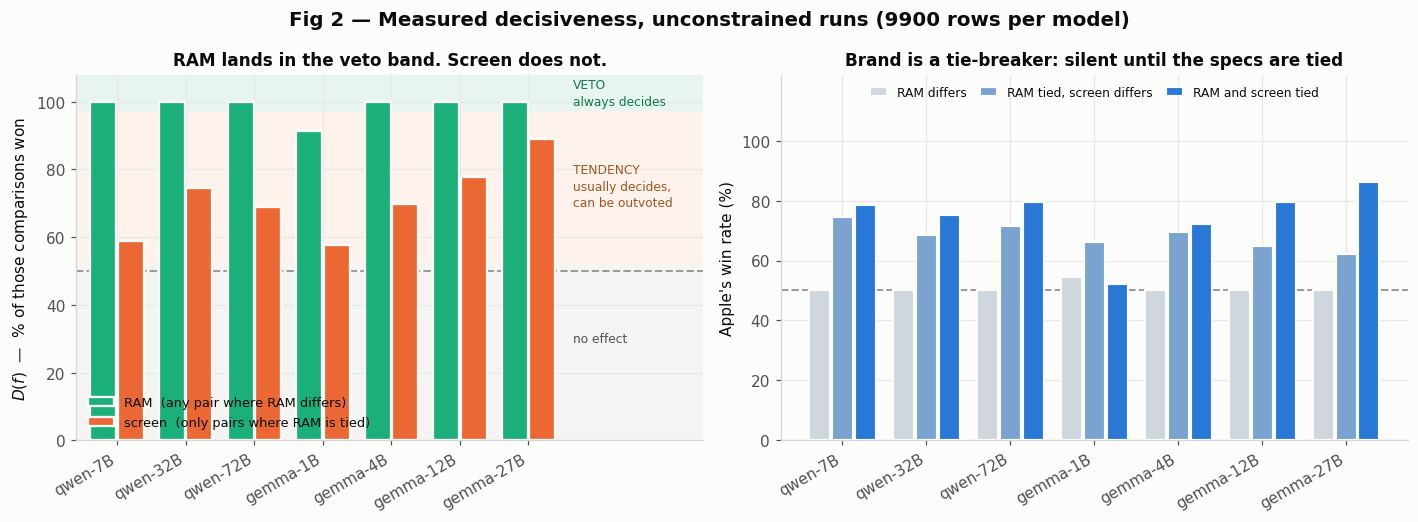

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(DEC))

ax = axes[0]
ax.axhspan(97, 108, color="#e8f4ee", zorder=0)
ax.axhspan(52, 97, color="#fdf3ec", zorder=0)
ax.axhspan(0, 52, color="#f4f4f2", zorder=0)
lx = len(DEC) - 0.35          # clear of the last bar
ax.text(lx, 102.5, "VETO\nalways decides", fontsize=8, color="#0f7a52",
        va="center", ha="left", linespacing=1.35)
ax.text(lx, 75, "TENDENCY\nusually decides,\ncan be outvoted", fontsize=8, color="#a4551f",
        va="center", ha="left", linespacing=1.35)
ax.text(lx, 30, "no effect", fontsize=8, color=INK_MUTED, va="center", ha="left")
ax.bar(x - 0.2, DEC.ram, 0.38, color=FEATURE_COLOR["ram"], edgecolor=SURFACE,
       linewidth=1.5, label="RAM  (any pair where RAM differs)", zorder=3)
ax.bar(x + 0.2, DEC.screen, 0.38, color=FEATURE_COLOR["screen"], edgecolor=SURFACE,
       linewidth=1.5, label="screen  (only pairs where RAM is tied)", zorder=3)
ax.axhline(50, color="#9c9b98", linewidth=1.3, linestyle="--", zorder=2)
ax.set_xticks(x, DEC.model, rotation=30, ha="right")
ax.set_ylim(0, 108)
ax.set_xlim(-0.6, len(DEC) + 1.55)
ax.set_ylabel("$D(f)$  —  % of those comparisons won")
ax.set_title("RAM lands in the veto band. Screen does not.", fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5, frameon=False, loc="lower left")
ax.grid(axis="y", zorder=1)

ax = axes[1]
cols = ["RAM differs", "RAM tied, screen differs", "RAM and screen tied"]
for i, (c, col) in enumerate(zip(cols, ["#cfd6de", "#7ba3d0", FEATURE_COLOR["brand"]])):
    ax.bar(x + (i - 1) * 0.27, APP[c], 0.25, color=col, edgecolor=SURFACE,
           linewidth=1.4, label=c, zorder=3)
ax.axhline(50, color="#9c9b98", linewidth=1.3, linestyle="--")
ax.set_xticks(x, APP.model, rotation=30, ha="right")
ax.set_ylim(0, 122)
ax.set_ylabel("Apple's win rate (%)")
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_title("Brand is a tie-breaker: silent until the specs are tied",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, frameon=False, loc="upper center", ncol=3,
          bbox_to_anchor=(0.5, 1.0), columnspacing=1.1, handlelength=1.4)

fig.suptitle("Fig 2 — Measured decisiveness, unconstrained runs (9900 rows per model)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**What Fig 2 shows.**

*Left panel.* The green RAM bars sit at **100.0%** for six of seven models — the laptop with
more RAM won **6750 out of 6750** comparisons. That is what I mean by a **veto**: it does not
matter what the other laptop had, more RAM won. The orange screen bars sit at 58-89%, inside
the **tendency** band: the bigger screen usually wins, but sometimes the other features
outvote it.

*Right panel.* The pale bars are Apple's win rate when RAM differs: exactly **50.0%**. Apple
wins precisely when it happens to have the bigger RAM, and never otherwise — brand
contributes *nothing*. Once RAM is tied (middle bars) and then screen too (dark bars), Apple
climbs to 56-87%. That is a **tie-breaker**.

gemma-1B is the exception on every panel. It is the smallest model and is noisy throughout.

# 5. Why this breaks the additive model

Here is the sharpest test, and it needs only one idea.

The additive model says a laptop's value is a **sum of separate parts**. So the brand part
must be the same number no matter what else is going on:

$$u(x) = \underbrace{w_{\text{brand}}(x)}_{\text{does not depend on RAM}} + w_{\text{screen}}(x) + w_{\text{ram}}(x)$$

So if we fit the brand weights **twice** — once using only the comparisons where RAM differs,
once using only the comparisons where RAM is tied — additivity says we must get **the same
answer**. Splitting the data should change how *precise* the estimate is, never what it is.

Let us do exactly that.

In [7]:
rows = []
for fam, s in REAL:
    d = RUNS[(fam, s, "none")]
    dif, tie = d[(d.a_ram != d.b_ram).values], d[(d.a_ram == d.b_ram).values]
    bd = np.array([fit_bt(dif)[f"brand_{b}"] for b in BRANDS])
    bt = np.array([fit_bt(tie, ("brand", "screen"))[f"brand_{b}"] for b in BRANDS])
    rows.append(dict(model=f"{fam}-{s}B",
                     spread_ram_differs=bd.max() - bd.min(),
                     spread_ram_tied=bt.max() - bt.min(),
                     apple_ram_differs=bd[1], apple_ram_tied=bt[1]))
SPL = pd.DataFrame(rows)
SPL["ratio"] = SPL.spread_ram_tied / SPL.spread_ram_differs
print("=== brand weights fitted on two halves of the SAME run ===")
print("'spread' = best brand minus worst brand. Additivity says the two must match.\n")
print(SPL.round(2).to_string(index=False))
print(f"\nn = 6750 rows (RAM differs) and 3150 rows (RAM tied)")
print(f"mean spread: {SPL.spread_ram_differs.mean():.2f} vs {SPL.spread_ram_tied.mean():.2f}"
      f"   -> {SPL.ratio.mean():.1f}x apart on average")

=== brand weights fitted on two halves of the SAME run ===
'spread' = best brand minus worst brand. Additivity says the two must match.

    model  spread_ram_differs  spread_ram_tied  apple_ram_differs  apple_ram_tied  ratio
  qwen-7B                0.32             2.65              -0.12            1.62   8.30
 qwen-32B                1.17             9.10               0.74            5.16   7.76
 qwen-72B                1.21             6.25               0.79            4.27   5.17
 gemma-1B                1.40             5.48               0.64            2.77   3.92
 gemma-4B                0.50             9.21               0.17            4.86  18.29
gemma-12B                1.05             5.31               0.61            2.64   5.05
gemma-27B                0.50            13.75               0.12            7.98  27.78

n = 6750 rows (RAM differs) and 3150 rows (RAM tied)
mean spread: 0.88 vs 7.39   -> 10.9x apart on average


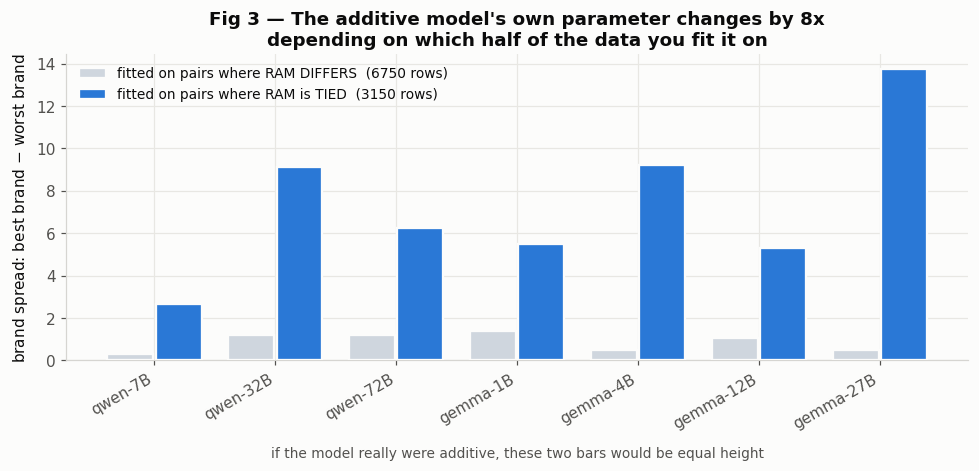

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.6))
x = np.arange(len(SPL))
ax.bar(x - 0.2, SPL.spread_ram_differs, 0.38, color="#cfd6de", edgecolor=SURFACE,
       linewidth=1.5, label="fitted on pairs where RAM DIFFERS  (6750 rows)", zorder=3)
ax.bar(x + 0.2, SPL.spread_ram_tied, 0.38, color=FEATURE_COLOR["brand"], edgecolor=SURFACE,
       linewidth=1.5, label="fitted on pairs where RAM is TIED  (3150 rows)", zorder=3)
ax.set_xticks(x, SPL.model, rotation=30, ha="right")
ax.set_ylabel("brand spread: best brand $-$ worst brand")
ax.legend(fontsize=9, frameon=False)
ax.set_title("Fig 3 — The additive model's own parameter changes by 8x\n"
             "depending on which half of the data you fit it on",
             fontsize=12, fontweight="bold")
ax.text(0.5, -0.28, "if the model really were additive, these two bars would be equal height",
        transform=ax.transAxes, ha="center", va="top", fontsize=9, color=INK_MUTED)
plt.tight_layout()
plt.show()

**What Fig 3 shows.** The pale bar is the brand effect measured on the 6750 comparisons where
RAM differs; the blue bar is the same quantity measured on the 3150 comparisons where RAM is
tied. Same run, same model, same 45 laptops.

They are **8x apart** on average (0.88 vs 7.39). When RAM differs, the brand effect is
essentially zero. When RAM is tied, it is large.

**Additivity forbids this.** A "part" that changes size depending on the company it keeps is
not a separate part. And it is not a statistical accident: brand and RAM are *exactly*
orthogonal in this design (a full factorial), so the two halves carry independent
information about brand.

## But then why did the additive fit look fine? ($R^2 \approx 0.85$)

Because when one weight is huge, an additive model **imitates** a priority list.

Look at the fitted numbers. If the biggest possible brand swing plus the biggest possible
screen swing is still smaller than the smallest RAM step, then the additive model itself can
never let brand overturn RAM:

$$\underbrace{\max_b w_{\text{brand}} - \min_b w_{\text{brand}}}_{\text{brand swing}} \;+\;
\underbrace{\max_s w_{\text{screen}} - \min_s w_{\text{screen}}}_{\text{screen swing}}
\;\;\overset{?}{<}\;\;
\underbrace{\min\big(w_{16\text{GB}} - w_{8\text{GB}},\; w_{8\text{GB}} - w_{4\text{GB}}\big)}_{\text{smallest RAM step}}$$

In [9]:
rows = []
for fam, s in REAL:
    w = fit_bt(RUNS[(fam, s, "none")])
    rs = [w[f"ram_{l}"] for l in RM]
    bsw = max(w[f"brand_{b}"] for b in BRANDS) - min(w[f"brand_{b}"] for b in BRANDS)
    ssw = max(w[f"screen_{l}"] for l in SC) - min(w[f"screen_{l}"] for l in SC)
    step = min(rs[1] - rs[0], rs[2] - rs[1])
    rows.append(dict(model=f"{fam}-{s}B", brand_swing=bsw, screen_swing=ssw,
                     both=bsw + ssw, smallest_ram_step=step,
                     can_brand_ever_win="YES" if bsw + ssw > step else "NO"))
print(pd.DataFrame(rows).round(2).to_string(index=False))

    model  brand_swing  screen_swing  both  smallest_ram_step can_brand_ever_win
  qwen-7B         0.86          3.90  4.76              12.60                 NO
 qwen-32B         3.82          4.65  8.47              15.70                 NO
 qwen-72B         2.84          4.26  7.10              11.47                 NO
 gemma-1B         2.76          2.48  5.24               7.00                 NO
 gemma-4B         3.41          3.94  7.35              14.00                 NO
gemma-12B         2.47          4.29  6.76              12.39                 NO
gemma-27B         4.88          6.78 11.66              14.61                 NO


**"NO" for every model.** The fitted additive model already behaves like a priority list.

So the additive fit is not *wrong about who wins* — that is why $R^2$ is high. It is wrong
about **what its own numbers mean**:

- The exchange rate it implies (roughly "11 Apples buy one RAM step") describes a trade the
  model will never make, at any price.
- Its brand weight is a blend of two incompatible situations, so its size depends on which
  comparisons you feed it (Fig 3).

**The practical rule:** use the additive fit for **ranking**. Do not read its magnitudes as
trade-offs, and never quote a brand weight without saying which comparisons produced it.

# 6. Now the contract

Everything above was with the plain prompt *"I am looking to buy a laptop."*

Now we add a spec, e.g. *"...I prefer 8 GB ram."* Does that change the priority list?

**Definition — compliance.** A laptop **complies** if it matches every level the contract
names. Reading it straight from `config.json`, where `constraints` is now a dict like
`{"ram": "8GB"}`:

$$C(x) = 1 \iff x_f = \ell_f \ \text{ for every } (f,\ell_f) \text{ in the contract}$$

**The idea of the test.** Most comparisons tell us nothing, because the contract and the
model's own preference agree. We need the pairs where they **disagree**:

| pair | contract prefers | the model's own RAM rule prefers | useful? |
|---|---|---|---|
| 8GB vs 16GB | **8GB** (it complies) | **16GB** (more RAM) | **yes — they conflict** |
| 8GB vs 4GB | 8GB | 8GB | no, they agree |
| 4GB vs 16GB | neither complies | 16GB | no, contract is silent |

**Definition — the conflict set.** Pairs where exactly one laptop complies, and it is the one
with *less* RAM:

$$K \;=\; \big\{(x,y) \;:\; C(x)=1,\; C(y)=0,\; \text{ram}(x) < \text{ram}(y) \big\}$$

**Definition — override rate.** How often the contract wins inside the conflict set:

$$O \;=\; \Pr\big[\,x \text{ is picked} \;\big|\; (x,y) \in K \,\big]$$

- $O \approx 0\%$ → the contract lost. RAM is still the veto.
- $O \approx 100\%$ → the contract is the new veto. The priority list changed.
- in between → they now genuinely trade off.

In [10]:
def complies(d, con, side):
    ok = np.ones(len(d), bool)
    for f, lvl in con.items():
        ok &= (d[f"{side}_{f}"] == lvl).values
    return ok


def pair_on(d, x, y, col):
    return (((d[f"a_{col}"] == x) & (d[f"b_{col}"] == y))
            | ((d[f"a_{col}"] == y) & (d[f"b_{col}"] == x))).values


rows = []
for fam, s in REAL:
    r = {"model": f"{fam}-{s}B"}
    # the conflict: 8GB (complies) vs 16GB (more RAM)
    for lab, key in [("no contract", "none"), ("under ram=8GB", "ram=8GB")]:
        d = RUNS[(fam, s, key)]
        r[lab] = wins(d, pair_on(d, "8GB", "16GB", "ram"), (d.a_ram == "8GB").values)
    # controls, same constrained run
    d = RUNS[(fam, s, "ram=8GB")]
    r["control: 4 vs 16"] = wins(d, pair_on(d, "4GB", "16GB", "ram"),
                                 (d.a_ram == "16GB").values)
    r["control: 8 vs 4"] = wins(d, pair_on(d, "8GB", "4GB", "ram"),
                                (d.a_ram == "8GB").values)
    rows.append(r)
CONF = pd.DataFrame(rows)
print("=== the conflict: 8GB vs 16GB, % where the COMPLIANT (8GB) laptop wins ===\n")
print(CONF[["model", "no contract", "under ram=8GB"]].round(1).to_string(index=False))
print("\n=== controls, from the SAME constrained run ===")
print("'4 vs 16': neither complies, contract silent -> % where 16GB (model's own choice) wins")
print("'8 vs 4' : contract and model agree          -> % where 8GB wins\n")
print(CONF[["model", "control: 4 vs 16", "control: 8 vs 4"]].round(1).to_string(index=False))

=== the conflict: 8GB vs 16GB, % where the COMPLIANT (8GB) laptop wins ===

    model  no contract  under ram=8GB
  qwen-7B          0.0           60.0
 qwen-32B          0.0           59.1
 qwen-72B          0.0           84.8
 gemma-1B          8.4           10.0
 gemma-4B          0.0           15.9
gemma-12B          0.0           54.5
gemma-27B          0.0           93.2

=== controls, from the SAME constrained run ===
'4 vs 16': neither complies, contract silent -> % where 16GB (model's own choice) wins
'8 vs 4' : contract and model agree          -> % where 8GB wins

    model  control: 4 vs 16  control: 8 vs 4
  qwen-7B             100.0            100.0
 qwen-32B             100.0            100.0
 qwen-72B              97.1            100.0
 gemma-1B              98.7             96.9
 gemma-4B             100.0            100.0
gemma-12B             100.0            100.0
gemma-27B             100.0            100.0


In [11]:
rows = []
for fam, s in REAL:
    r = {"model": f"{fam}-{s}B"}
    for lab, key in [("no contract", "none"), ("under screen=14-inch", "screen=14-inch")]:
        d = RUNS[(fam, s, key)]
        m = pair_on(d, "14-inch", "16-inch", "screen") & (d.a_ram == d.b_ram).values
        r[lab] = wins(d, m, (d.a_screen == "14-inch").values)
    rows.append(r)
SCR = pd.DataFrame(rows)
print("=== the same conflict for the SCREEN contract ===")
print("RAM-tied pairs only, 14-inch vs 16-inch. Models' own order prefers the bigger screen.")
print("(% where the compliant 14-inch wins)\n")
print(SCR.round(1).to_string(index=False))

=== the same conflict for the SCREEN contract ===
RAM-tied pairs only, 14-inch vs 16-inch. Models' own order prefers the bigger screen.
(% where the compliant 14-inch wins)

    model  no contract  under screen=14-inch
  qwen-7B         39.3                  96.4
 qwen-32B         29.2                 100.0
 qwen-72B         34.0                 100.0
 gemma-1B         45.5                  37.1
 gemma-4B         24.8                  49.7
gemma-12B         20.5                 100.0
gemma-27B         11.2                 100.0


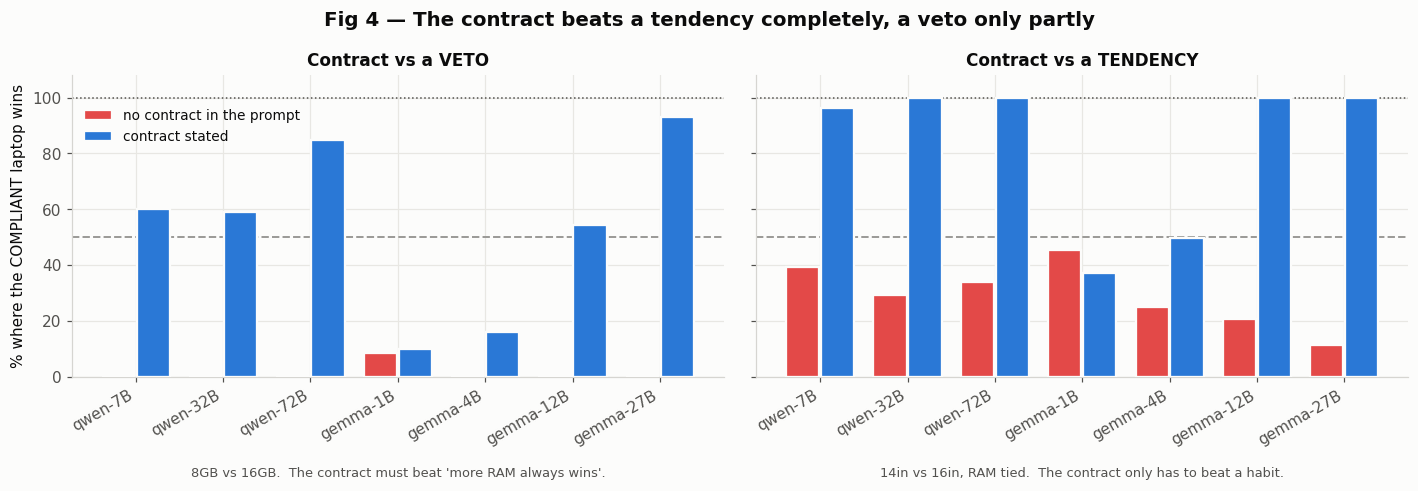

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, (T, a, b, title, sub) in zip(axes, [
        (CONF, "no contract", "under ram=8GB",
         "Contract vs a VETO",
         "8GB vs 16GB.  The contract must beat 'more RAM always wins'."),
        (SCR, "no contract", "under screen=14-inch",
         "Contract vs a TENDENCY",
         "14in vs 16in, RAM tied.  The contract only has to beat a habit.")]):
    x = np.arange(len(T))
    ax.bar(x - 0.2, T[a], 0.38, color=OWN, edgecolor=SURFACE, linewidth=1.5,
           label="no contract in the prompt", zorder=3)
    ax.bar(x + 0.2, T[b], 0.38, color=CONTRACT, edgecolor=SURFACE, linewidth=1.5,
           label="contract stated", zorder=3)
    ax.axhline(50, color="#9c9b98", linewidth=1.3, linestyle="--")
    ax.axhline(100, color=INK_MUTED, linewidth=1, linestyle=":")
    ax.set_xticks(x, T.model, rotation=30, ha="right")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.text(0.5, -0.30, sub, transform=ax.transAxes, ha="center", va="top",
            fontsize=8.5, color=INK_MUTED)
    ax.set_ylim(0, 108)
axes[0].set_ylabel("% where the COMPLIANT laptop wins")
axes[0].legend(fontsize=9, frameon=False, loc="upper left", bbox_to_anchor=(0.0, 0.93))
fig.suptitle("Fig 4 — The contract beats a tendency completely, a veto only partly",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**What Fig 4 shows.** Each pair of bars is one model. Red = the same comparison with no
contract in the prompt; blue = with the contract.

*Left (contract vs a veto).* Red bars are at **0%** — without a contract, the 8GB laptop
never beats the 16GB one. With the `ram=8GB` contract the blue bars rise to **54-93%** for
the capable models. The veto is **broken**, but it is not replaced: nothing reaches 100%. RAM
and compliance now genuinely trade off.

*Right (contract vs a tendency).* Without a contract the 14-inch wins only 11-45% (the models
like bigger screens). With the `screen=14-inch` contract it jumps to **96-100%** for five of
seven models. Here the contract really does become the new **veto** — the priority list
changed.

**The controls matter** (printed above, not plotted). Inside the *same* constrained run,
where the contract has nothing to say (4GB vs 16GB), the RAM veto is untouched at 97-100%.
So the contract does not make the model generally confused. It acts only where it applies.

**The lesson: a contract's power depends on what it is fighting.** Asking for something the
model was flexible about is obeyed completely. Asking it to give up the thing it always wants
is obeyed only partly.

# 7. Override rate as an adherence score

Section 6 suggests a cleaner way to measure "does the model listen": the override rate $O$
defined above, computed across all three contracts.

It is a percentage, it needs no fitted model, and the scale problem cannot touch it.

In [13]:
CLAB = {"screen=14-inch": "14in", "ram=8GB": "8GB", "ram=8GB+screen=14-inch": "14in+8GB"}
rows = []
for fam, s in REAL:
    r = {"model": f"{fam}-{s}B", "family": fam, "size": float(s)}
    for key, lab in CLAB.items():
        d, con = RUNS[(fam, s, key)], CONSTRAINTS[(fam, s, key)]
        ca, cb = complies(d, con, "a"), complies(d, con, "b")
        ra, rb = d.a_ram.map(RORD).values, d.b_ram.map(RORD).values
        K = ((ca & ~cb) & (ra < rb)) | ((cb & ~ca) & (rb < ra))     # the conflict set
        r[lab] = wins(d, K, ca)
        r[lab + " n"] = int(K.sum())
    rows.append(r)
OVR = pd.DataFrame(rows)
print("=== override rate O (%) — conflict pairs only ===\n")
print(OVR[["model", "14in", "8GB", "14in+8GB"]].round(1).to_string(index=False))
print("\nconflict-set sizes per model:",
      ", ".join(f"{l}={OVR[l+' n'].iloc[0]}" for l in CLAB.values()))

=== override rate O (%) — conflict pairs only ===

    model  14in  8GB  14in+8GB
  qwen-7B  24.9 60.0      71.2
 qwen-32B  68.7 59.1      79.3
 qwen-72B  64.7 84.8      83.3
 gemma-1B   7.3 10.0      18.3
 gemma-4B  16.9 15.9      53.9
gemma-12B  57.3 54.5      82.4
gemma-27B  85.0 93.2      84.3

conflict-set sizes per model: 14in=1500, 8GB=2250, 14in+8GB=750


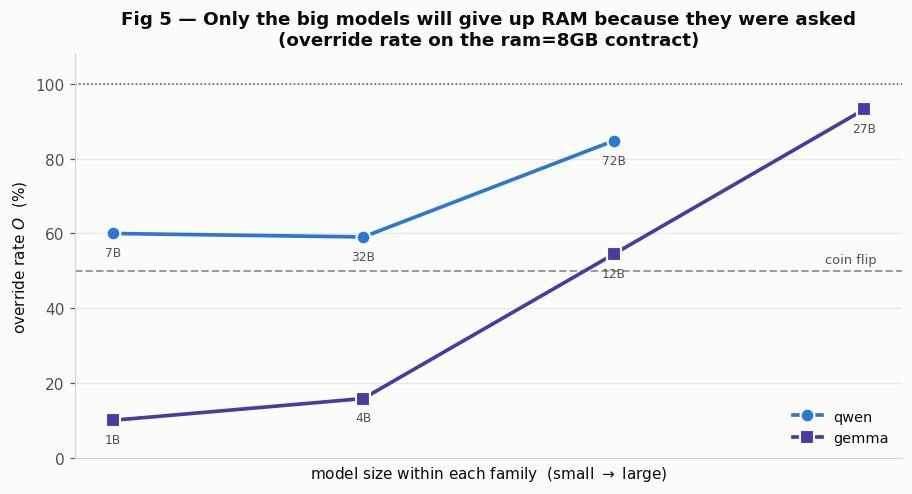

In [14]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
for fam, col, mk in [("qwen", "#2a78d6", "o"), ("gemma", "#4a3aa7", "s")]:
    sub = OVR[OVR.family == fam].sort_values("size")
    ax.plot(np.arange(len(sub)), sub["8GB"], marker=mk, markersize=9, linewidth=2.4,
            color=col, markeredgecolor=SURFACE, markeredgewidth=1.4, label=fam, zorder=3)
    for i, (_, r) in enumerate(sub.iterrows()):
        ax.annotate(f"{r['size']:g}B", (i, r["8GB"]), textcoords="offset points",
                    xytext=(0, -15), ha="center", fontsize=8, color=INK_MUTED)
ax.axhline(50, color="#9c9b98", linewidth=1.3, linestyle="--")
ax.text(3.05, 52, "coin flip", ha="right", fontsize=8.5, color=INK_MUTED)
ax.axhline(100, color=INK_MUTED, linewidth=1, linestyle=":")
ax.set_xticks([])
ax.set_xlabel("model size within each family  (small $\\rightarrow$ large)")
ax.set_ylabel("override rate $O$  (%)")
ax.set_ylim(0, 108)
ax.legend(frameon=False, fontsize=9.5)
ax.set_title("Fig 5 — Only the big models will give up RAM because they were asked\n"
             "(override rate on the ram=8GB contract)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**What Fig 5 shows.** One line per family, models ordered small to large, using the `ram=8GB`
column of the table above.

gemma climbs steadily: **10% → 16% → 54% → 93%**. qwen goes 60% → 59% → 85%.

This says something sharper than "big models follow instructions better". The small models
are not generally disobedient — look at the control column in section 6, where even gemma-1B
complies 97-100%. They fail at exactly one thing: **overruling their own strongest preference
because a user asked them to.**

# Glossary

| my word | standard term | definition | measured value here |
|---|---|---|---|
| **veto** | non-compensatory / lexicographic in that feature | $D(f) = 100\%$: whenever this feature differs, it decides, whatever else differs | RAM, with no contract: 6750/6750 |
| **tendency** | compensatory | $50\% < D(f) < 100\%$: usually decides, can be outvoted | screen: 58-89% |
| **tie-breaker** | lower in the lexicographic order | only speaks when the features above it are tied | brand: exactly 50% until specs tie |
| **exchange rate** | marginal rate of substitution | how much of one feature buys one step of another | does not exist here |
| **compliance** $C(x)$ | — | the laptop matches every level the contract names | from `config.json`'s `constraints` dict |
| **conflict set** $K$ | — | pairs where the compliant laptop is the one with *less* RAM | 750-2250 pairs per model |
| **override rate** $O$ | — | % of the conflict set won by the compliant laptop | 10-93%, scales with size |

# Summary in five sentences

1. With no contract, the models do **not** weigh features against each other — they walk down
   a priority list: RAM, then screen, then brand.
2. RAM is a **veto** (100%), screen is a **tendency** (58-89%), brand is a **tie-breaker**
   (exactly 50% until the specs are tied).
3. This breaks the additive model: its brand parameter changes **8x** depending on which half
   of the data you fit it on, which a sum of separate parts cannot do.
4. The additive fit still *predicts winners* well, because one huge weight imitates a priority
   list — so keep using it for **ranking**, and never read its magnitudes as trade-offs.
5. Stating a contract inserts it into the priority list: **completely** when it fights a
   tendency (96-100%), only **partly** when it fights a veto (54-93%), and that partial
   obedience is what scales with model size.